<a href="https://colab.research.google.com/github/HamidAliHassan/Coal-LOI-prediction/blob/main/Coal_LOI_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload your 'LOI % data.xlsx' file here:


Saving LOI % data.xlsx to LOI % data.xlsx
Dataset loaded successfully with 225 rows.
Target threshold (LOI < 1%) set to decimal: 0.01

--- Running Complex Model Comparison & Hyperparameter Tuning ---
Random Forest -> R² Score: 0.9913 | RMSE: 0.00023
Gradient Boosting -> R² Score: 0.9976 | RMSE: 0.00012
XGBoost (Tuned) -> R² Score: 0.9814 | RMSE: 0.00034

>> Selected Best Performing Model: Gradient Boosting <<


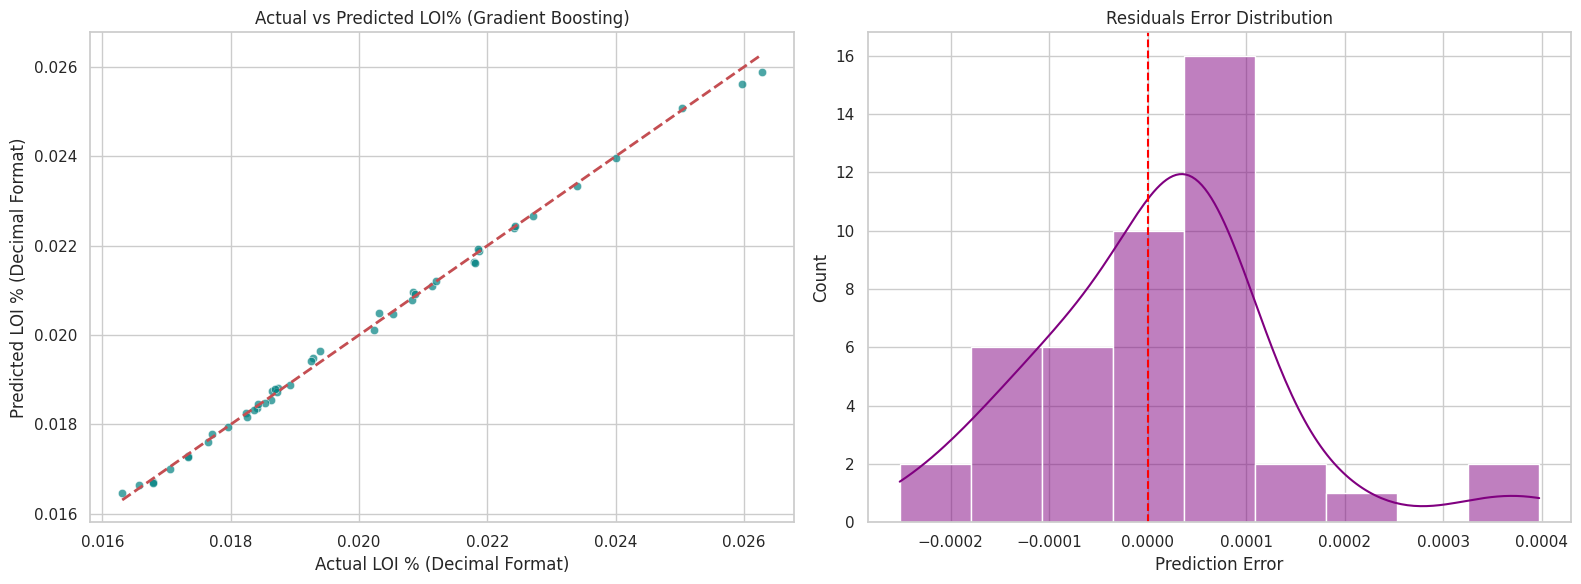


--- Generating SHAP Feature Impact Summary ---


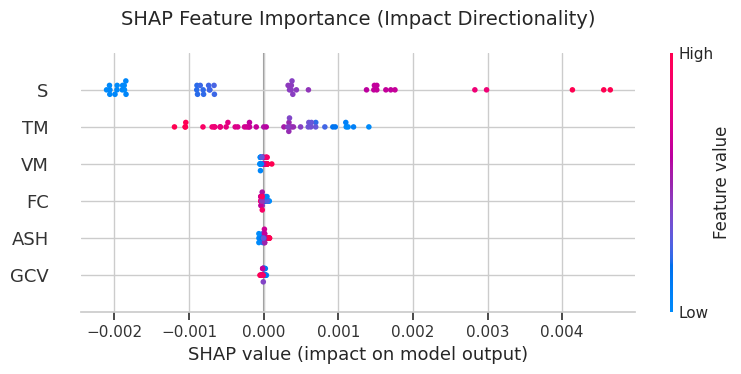


--- Identifying Optimal Combinations for LOI < 1% ---

No historical observations exist below 1% LOI.
Running a simulated matrix to find theoretical recipe combinations...

Target strictly unreachable under current physical material spectrum bounds.
Displaying top 5 configurations maximizing performance (Lowest achievable LOI%):
          TM      ASH       VM       FC        S     GCV     Loi %
1   0.098650  0.15955  0.33477  0.40736  0.00840  5702.1  0.016257
32  0.098310  0.15918  0.33071  0.41212  0.00856  5717.1  0.016265
9   0.097207  0.16229  0.31658  0.42432  0.00854  5700.6  0.016309
6   0.097214  0.16016  0.34076  0.40212  0.00838  5709.2  0.016513
54  0.096874  0.15979  0.33670  0.40688  0.00854  5724.2  0.016521


In [ ]:
# Install advanced interpretability libraries if not present
!pip install -q xgboost shap openpyxl

import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import shap

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ==========================================
# 1. LOAD AND PREPROCESS DATA
# ==========================================
file_name = 'LOI % data.xlsx - BLEND LOI% .csv'

try:
    # Try reading as Excel directly since the underlying structure is likely an Excel sheet
    df = pd.read_excel(file_name)
except Exception:
    from google.colab import files
    print("Please upload your 'LOI % data.xlsx' file here:")
    uploaded = files.upload()
    file_key = list(uploaded.keys())[0]

    # Check if file has binary Excel content, read accordingly
    if file_key.endswith('.xlsx') or b'PK\x03\x04' in uploaded[file_key][:4]:
        df = pd.read_excel(io.BytesIO(uploaded[file_key]))
    else:
        content = uploaded[file_key].decode('utf-8', errors='ignore')
        df = pd.read_csv(io.StringIO(content))

# Clean column spaces
df.columns = df.columns.str.strip()

# Target and Feature selection
features = ['TM', 'ASH', 'VM', 'FC', 'S', 'GCV']
target = 'Loi %'

# Enforce strict decimal threshold since data uses fractions (e.g., 0.019 = 1.9%)
loi_threshold = 0.01
print(f"Dataset loaded successfully with {df.shape[0]} rows.")
print(f"Target threshold (LOI < 1%) set to decimal: {loi_threshold}")

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 2. COMPLEX MODEL TESTING & TUNING
# ==========================================
print("\n--- Running Complex Model Comparison & Hyperparameter Tuning ---")

# Define hyperparameter search grid for XGBoost
xgb_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9]
}

models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost (Tuned)": RandomizedSearchCV(xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
                                         param_distributions=xgb_grid, n_iter=10,
                                         cv=3, scoring='neg_mean_squared_error',
                                         random_state=42, n_jobs=-1)
}

results = {}
best_model = None
best_r2 = -float('inf')

for name, model in models.items():
    if name == "XGBoost (Tuned)":
        model.fit(X_train, y_train)
        clf = model.best_estimator_
    else:
        clf = model.fit(X_train, y_train)

    preds = clf.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    print(f"{name} -> R² Score: {r2:.4f} | RMSE: {rmse:.5f}")

    if r2 > best_r2:
        best_r2 = r2
        best_model_name = name
        best_model = clf

print(f"\n>> Selected Best Performing Model: {best_model_name} <<")

# ==========================================
# 3. ADVANCED GRAPHICAL DIAGNOSTICS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Prediction vs Actual
test_preds = best_model.predict(X_test)
sns.scatterplot(x=y_test, y=test_preds, ax=axes[0], alpha=0.7, color='teal')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(f'Actual vs Predicted LOI% ({best_model_name})')
axes[0].set_xlabel('Actual LOI % (Decimal Format)')
axes[0].set_ylabel('Predicted LOI % (Decimal Format)')

# Plot 2: Residual Analysis
residuals = y_test - test_preds
sns.histplot(residuals, kde=True, ax=axes[1], color='purple')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residuals Error Distribution')
axes[1].set_xlabel('Prediction Error')
plt.tight_layout()
plt.show()

# ==========================================
# 4. EXPLAINING DRIVING FACTORS (SHAP VISUALIZATION)
# ==========================================
print("\n--- Generating SHAP Feature Impact Summary ---")
explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Feature Importance (Impact Directionality)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# ==========================================
# 5. FIND OPTIMAL CONFIGURATIONS FOR LOI < 1% (0.01)
# ==========================================
print("\n--- Identifying Optimal Combinations for LOI < 1% ---")

empirical_success = df[df[target] < loi_threshold]

if len(empirical_success) > 0:
    print(f"\nFound {len(empirical_success)} historical blends matching LOI < 1%.")
    print("\nOperational parameter ranges to safely yield LOI < 1%:")
    print(empirical_success[features].agg(['min', 'mean', 'max']).T)
else:
    print("\nNo historical observations exist below 1% LOI.")
    print("Running a simulated matrix to find theoretical recipe combinations...")

    # Generate 50k points across the uniform boundary constraints of real coal inputs
    synthetic_grid = np.random.uniform(X.min().values, X.max().values, size=(50000, len(features)))
    synthetic_df = pd.DataFrame(synthetic_grid, columns=features)
    synthetic_df['Predicted_LOI'] = best_model.predict(synthetic_df)

    simulated_success = synthetic_df[synthetic_df['Predicted_LOI'] < loi_threshold]

    if len(simulated_success) > 0:
        print(f"\nSuccessfully reverse-engineered {len(simulated_success)} synthetic blend paths matching your target.")
        print("\nTarget Operational Ranges (Calculated From Simulation Engine):")
        print(simulated_success[features].agg(['min', 'mean', 'max']).T)
    else:
        print("\nTarget strictly unreachable under current physical material spectrum bounds.")
        print("Displaying top 5 configurations maximizing performance (Lowest achievable LOI%):")
        print(df.nsmallest(5, target)[features + [target]])